In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url = 'C:/Users/HP/OneDrive/Desktop/GUVI-DS PROJECT REPORTS/youtube_ad_revenue_dataset.csv'
data = pd.read_csv(url)

In [4]:
data.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  object 
 1   date                  122400 non-null  object 
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  object 
 9   device                122400 non-null  object 
 10  country               122400 non-null  object 
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 11.2+ MB


In [6]:
data.shape

(122400, 12)

Checking null percentage

In [7]:
100*data.isnull().sum()/len(data)

video_id                0.000000
date                    0.000000
views                   0.000000
likes                   4.997549
comments                4.993464
watch_time_minutes      4.987745
video_length_minutes    0.000000
subscribers             0.000000
category                0.000000
device                  0.000000
country                 0.000000
ad_revenue_usd          0.000000
dtype: float64

Handling missing values

In [8]:
#Dropping null value rows as null percentage is less than 5%
data.dropna(subset = ['watch_time_minutes', 'comments',  'likes'], inplace=True)     

In [9]:
100*data.isnull().sum()/len(data)     #Checking null percentage again

video_id                0.0
date                    0.0
views                   0.0
likes                   0.0
comments                0.0
watch_time_minutes      0.0
video_length_minutes    0.0
subscribers             0.0
category                0.0
device                  0.0
country                 0.0
ad_revenue_usd          0.0
dtype: float64

In [10]:
data.shape

(104955, 12)

Checking Datatypes of each column

In [11]:
data.dtypes

video_id                 object
date                     object
views                     int64
likes                   float64
comments                float64
watch_time_minutes      float64
video_length_minutes    float64
subscribers               int64
category                 object
device                   object
country                  object
ad_revenue_usd          float64
dtype: object

Likes and Comments should be in int

In [12]:
data['likes'] = data['likes'].astype('int64')
data['comments'] = data['comments'].astype('int64')

Date column should have date data type

In [13]:
data['date'] = pd.to_datetime(data['date']).dt.date

In [14]:
data['date'] = data['date'].astype('datetime64[ns]')

In [15]:
data.dtypes                        #Checking for data types again

video_id                        object
date                    datetime64[ns]
views                            int64
likes                            int64
comments                         int64
watch_time_minutes             float64
video_length_minutes           float64
subscribers                      int64
category                        object
device                          object
country                         object
ad_revenue_usd                 float64
dtype: object

In [16]:
data.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24,9936,1221,320,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22,10017,642,346,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21,10097,1979,187,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28,10034,1191,242,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28,9889,1858,477,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


Univariate Analysis

Understanding category columns

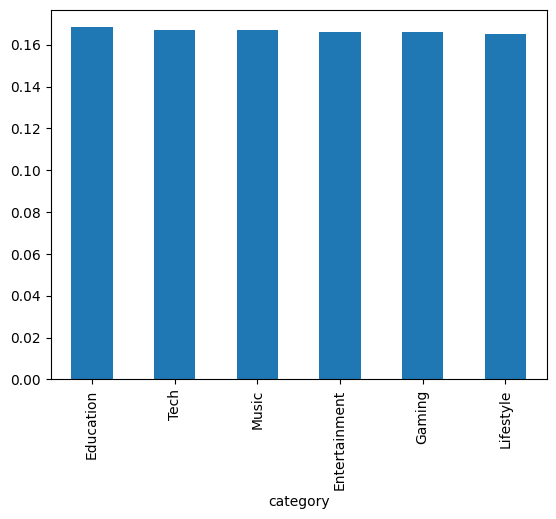

In [17]:
data['category'].value_counts(normalize = True).plot.bar()
plt.show()

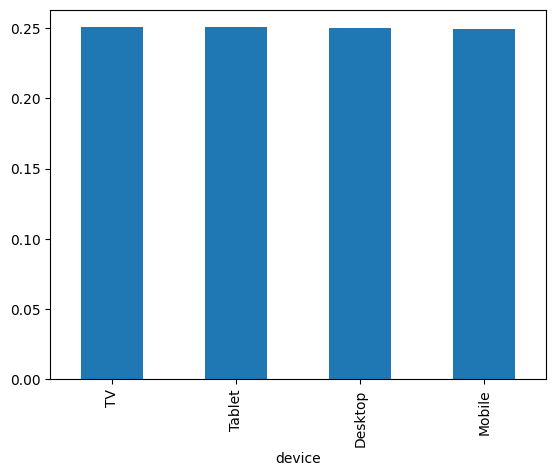

In [18]:
data['device'].value_counts(normalize = True).plot.bar()
plt.show()

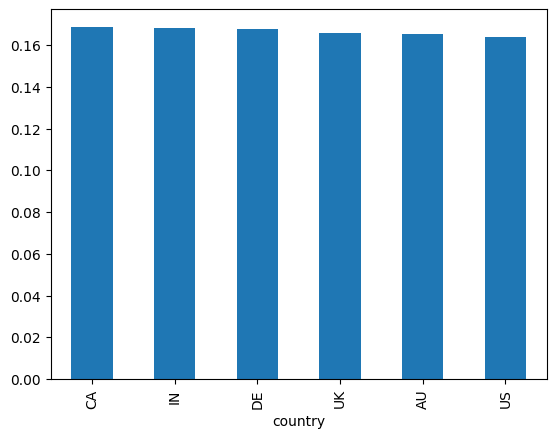

In [19]:
data['country'].value_counts(normalize = True).plot.bar()
plt.show()

Understanding Numeric columns

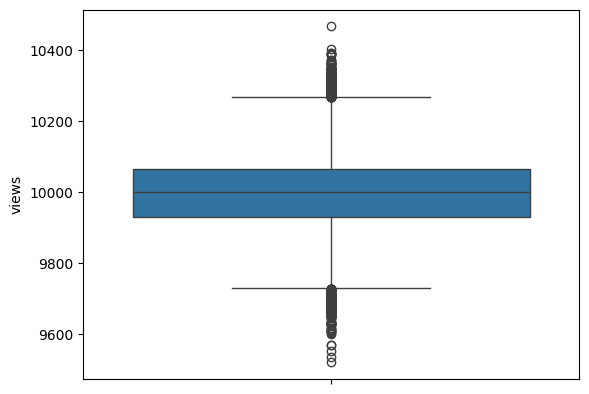

In [20]:
sns.boxplot(data['views'])
plt.show()

Having outliers in views column is common because those indicate viral videos, so we should not remove them

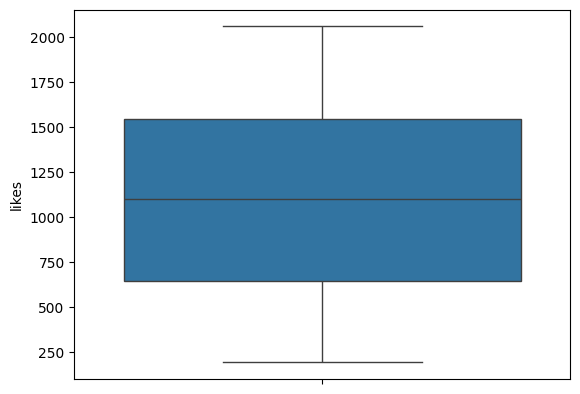

In [21]:
sns.boxplot(data['likes'])
plt.show()

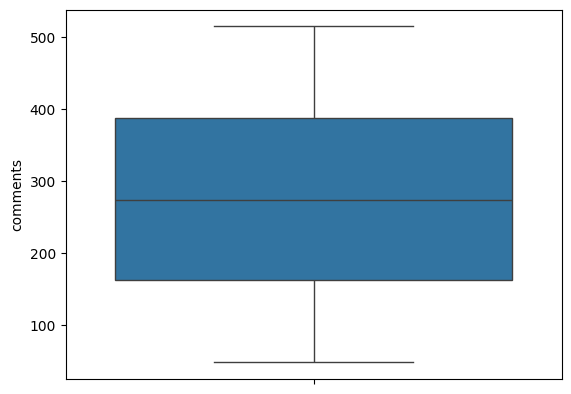

In [22]:
sns.boxplot(data['comments'])
plt.show()

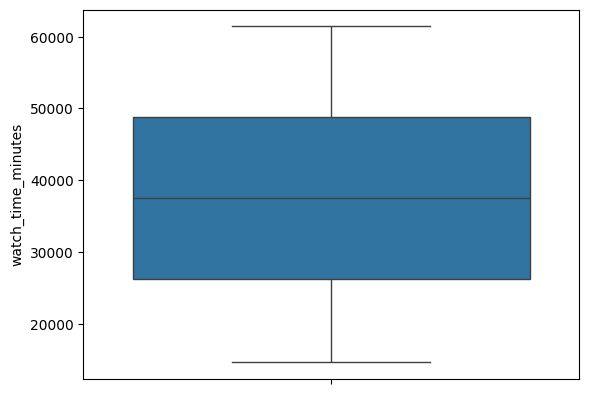

In [23]:
sns.boxplot(data['watch_time_minutes'])
plt.show()

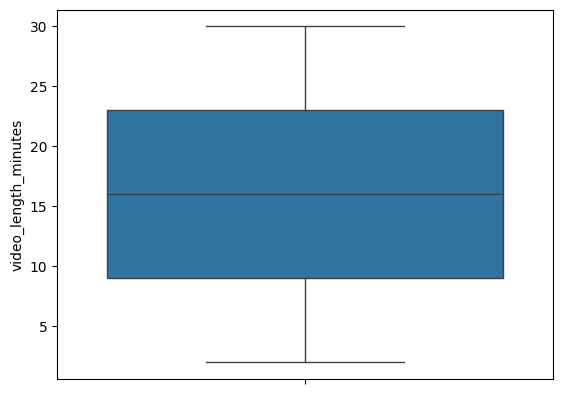

In [24]:
sns.boxplot(data['video_length_minutes'])
plt.show()

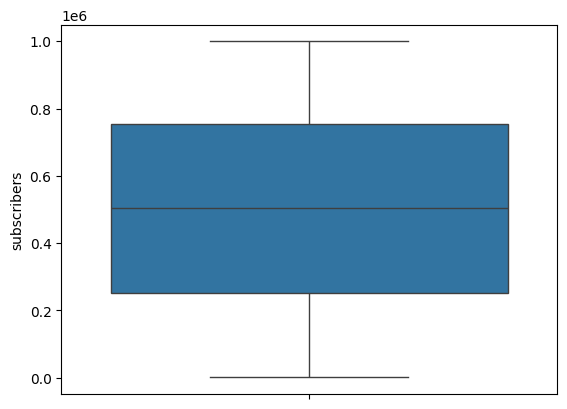

In [25]:
sns.boxplot(data['subscribers'])
plt.show()

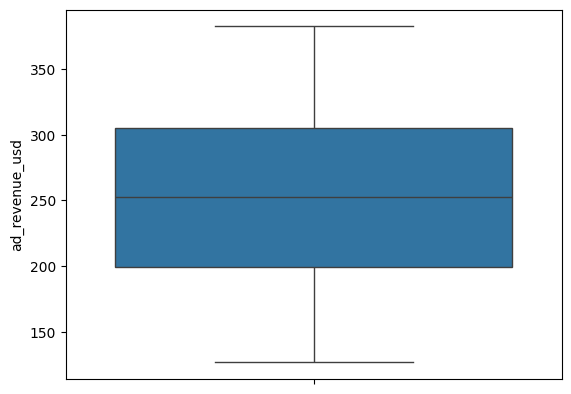

In [26]:
sns.boxplot(data['ad_revenue_usd'])
plt.show()

Bivariate Analysis

Category - Numeric

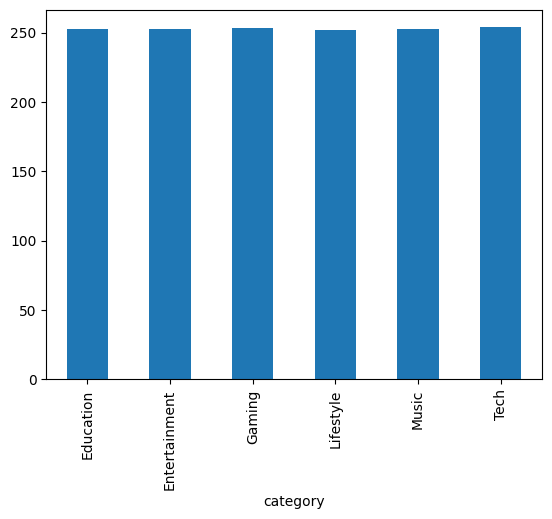

In [27]:
data.groupby('category')['ad_revenue_usd'].mean().plot.bar()
plt.show()

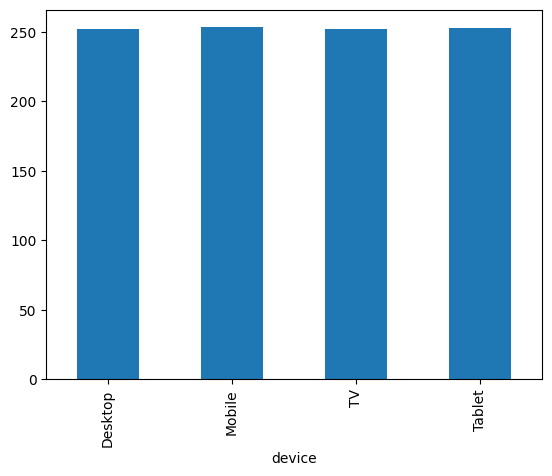

In [28]:
data.groupby('device')['ad_revenue_usd'].mean().plot.bar()
plt.show()

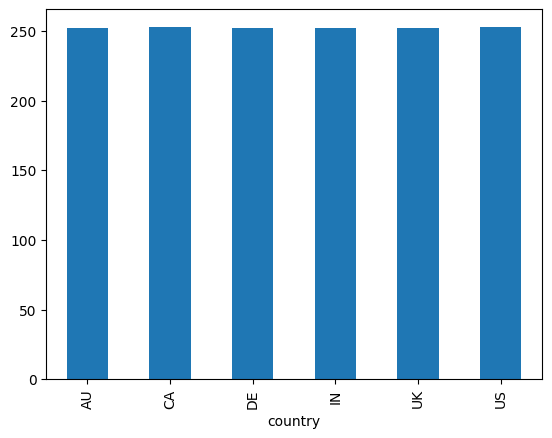

In [29]:
data.groupby('country')['ad_revenue_usd'].mean().plot.bar()
plt.show()

Numeric-Numeric

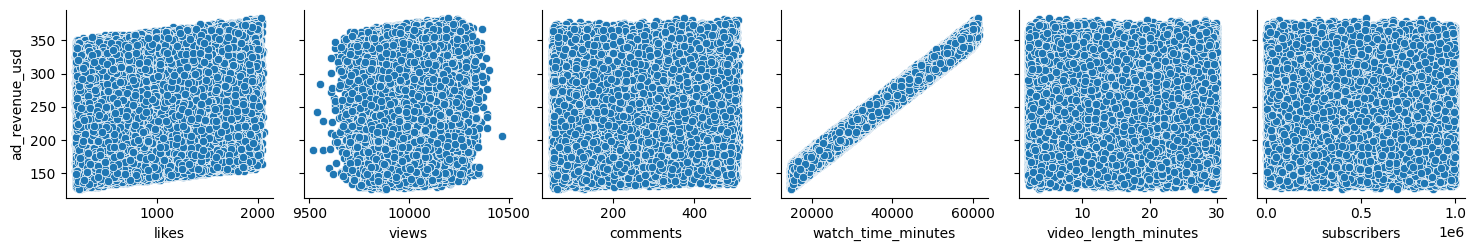

In [30]:
sns.pairplot(data=data, x_vars=['likes', 'views', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers'], y_vars='ad_revenue_usd')
plt.show()

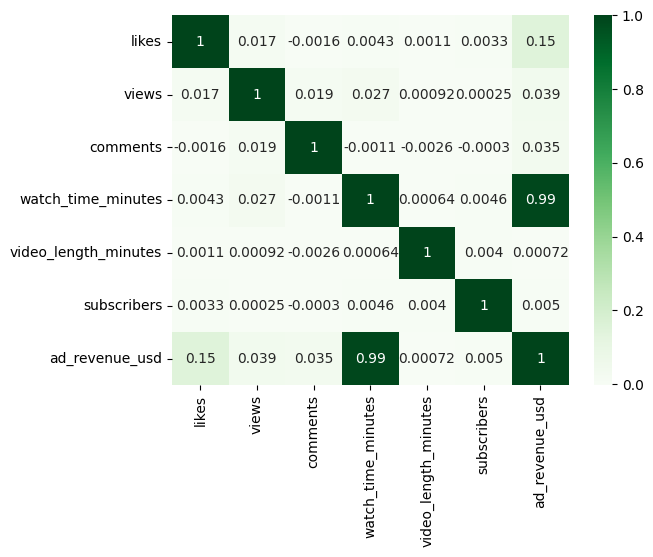

In [31]:
sns.heatmap(data[['likes', 'views', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers', 'ad_revenue_usd']].corr(), annot=True, cmap = 'Greens')
plt.show()

Multivariate Analysis

In [32]:
pd.pivot_table(data=data, index='category', columns='country', values='ad_revenue_usd', aggfunc='mean')

country,AU,CA,DE,IN,UK,US
category,,,,,,
Education,252.010589,252.761472,253.542247,251.406125,250.959518,253.191129
Entertainment,252.292810,252.607986,252.458400,251.781818,252.471129,251.932609
Gaming,252.786866,253.629744,253.700792,252.192651,254.038089,254.328480
Lifestyle,251.679789,252.038028,251.259123,252.539288,251.633446,251.347112
Music,252.722524,251.822994,250.508822,253.524134,251.620761,253.781777
Tech,253.588038,253.801869,252.939609,253.984389,254.122222,253.651354


Feature Engineering

In [33]:
data['Day_of_Week'] = data['date'].dt.day_name()

In [34]:
data['Month'] = data['date'].dt.month

In [35]:
data.drop(['date', 'video_id'], axis=1, inplace=True)    #Dropping date and video_id columns as we do not need them for model training

In [36]:
data.head()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,Day_of_Week,Month
0,9936,1221,320,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,Tuesday,9
1,10017,642,346,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,Sunday,9
2,10097,1979,187,57332.658498,26.200634,240534,Education,TV,CA,360.134008,Thursday,11
3,10034,1191,242,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,Tuesday,1
4,9889,1858,477,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,Monday,4


Encoding

In [37]:
#Creating dummy variables for categorical columns
dummies = pd.get_dummies(data[['category', 'device', 'country', 'Day_of_Week']])
#Adding those columns to the main data frame
data = pd.concat([data, dummies], axis=1)

In [38]:
data.columns

Index(['views', 'likes', 'comments', 'watch_time_minutes',
       'video_length_minutes', 'subscribers', 'category', 'device', 'country',
       'ad_revenue_usd', 'Day_of_Week', 'Month', 'category_Education',
       'category_Entertainment', 'category_Gaming', 'category_Lifestyle',
       'category_Music', 'category_Tech', 'device_Desktop', 'device_Mobile',
       'device_TV', 'device_Tablet', 'country_AU', 'country_CA', 'country_DE',
       'country_IN', 'country_UK', 'country_US', 'Day_of_Week_Friday',
       'Day_of_Week_Monday', 'Day_of_Week_Saturday', 'Day_of_Week_Sunday',
       'Day_of_Week_Thursday', 'Day_of_Week_Tuesday', 'Day_of_Week_Wednesday'],
      dtype='object')

In [39]:
#Dropping the categorical columns for which dummies are created
data.drop(['category', 'device', 'country', 'Day_of_Week'], axis=1, inplace=True)

In [40]:
data.head()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd,Month,category_Education,category_Entertainment,...,country_IN,country_UK,country_US,Day_of_Week_Friday,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday
0,9936,1221,320,26497.214184,2.862137,228086,203.178237,9,False,True,...,True,False,False,False,False,False,False,False,True,False
1,10017,642,346,15209.747445,23.738069,736015,140.880508,9,False,False,...,False,False,False,False,False,False,True,False,False,False
2,10097,1979,187,57332.658498,26.200634,240534,360.134008,11,True,False,...,False,False,False,False,False,False,False,True,False,False
3,10034,1191,242,31334.517771,11.770340,434482,224.638261,1,False,True,...,False,True,False,False,False,False,False,False,True,False
4,9889,1858,477,15665.666434,6.635854,42030,165.514388,4,True,False,...,False,False,False,False,True,False,False,False,False,False


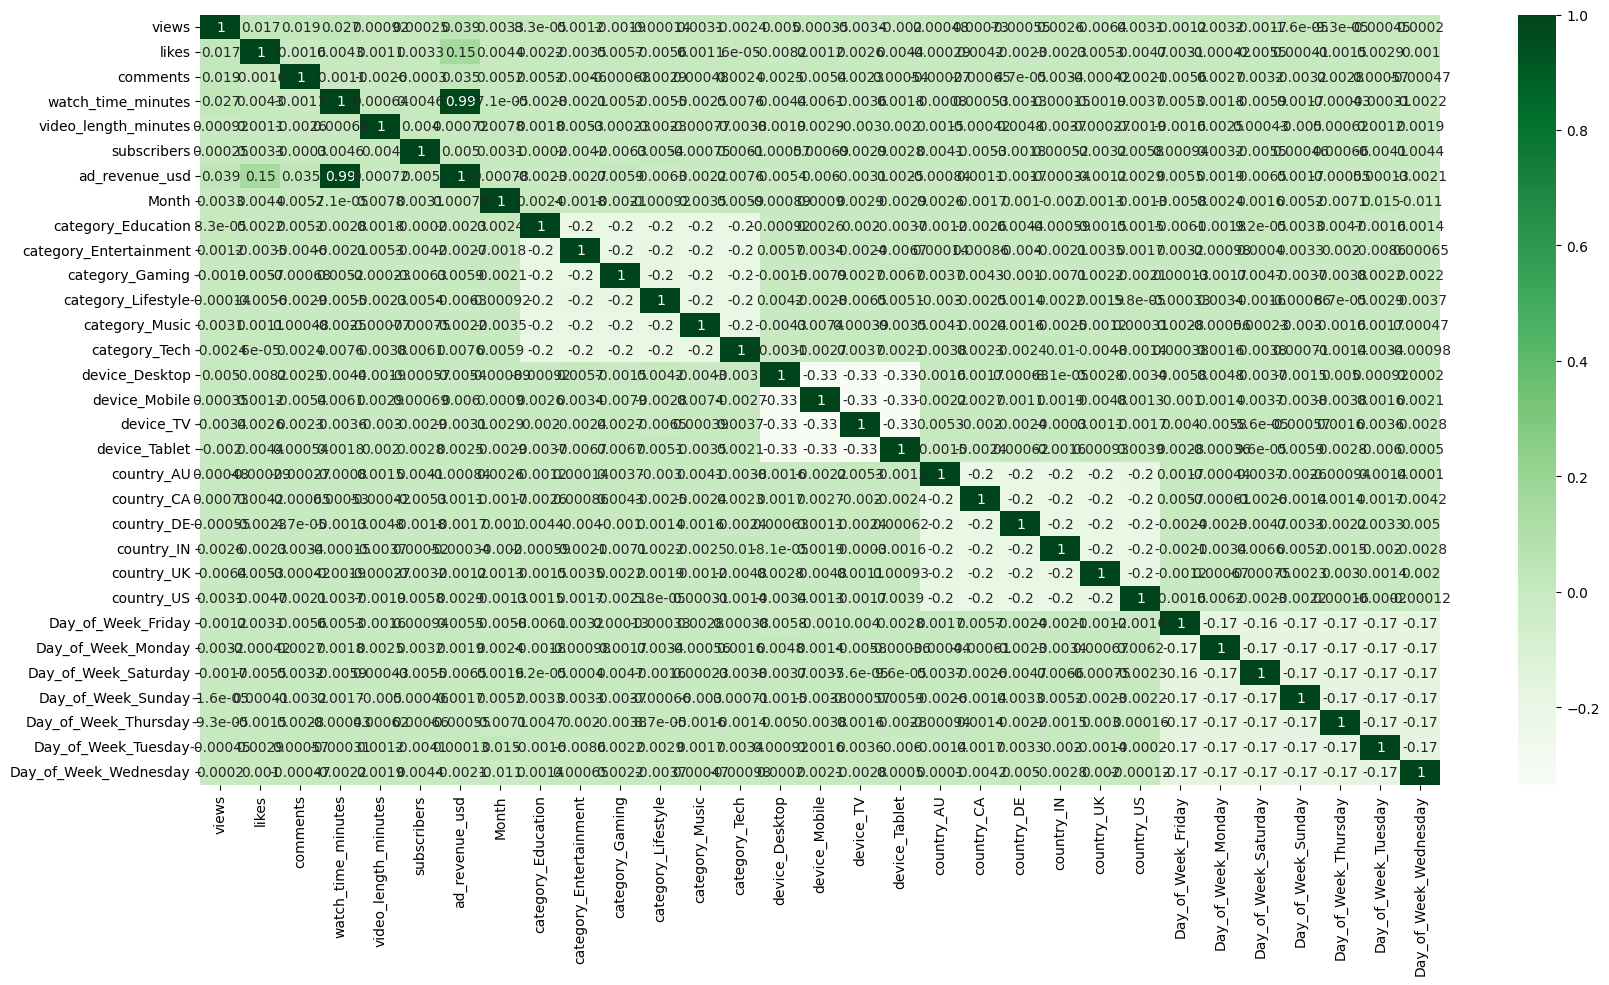

In [41]:
plt.figure(figsize = (20,10)) 
sns.heatmap(data.corr(), annot=True, cmap='Greens')
plt.show()

In [42]:
data.to_csv('C:/Users/HP/OneDrive/Desktop/GUVI-DS PROJECT REPORTS/youtube_revenue_cleaned.csv')